In [ ]:
# Add this to your Colab to generate it
from tensorflow.keras.utils import plot_model

plot_model(models['Neural Network'],
           to_file='/content/drive/MyDrive/nn_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',
           dpi=200)
```

This creates a visual flowchart:
```
Input (10 features)
    ↓
Dense Layer (128)
    ↓
Dropout (0.3)
    ↓
Dense Layer (64)
    ↓
Dropout (0.3)
    ↓
Dense Layer (32)
    ↓
Output (1)

SyntaxError: invalid character '↓' (U+2193) (ipython-input-1011365710.py, line 15)

In [ ]:
# ============================================================================
# ADDITIONAL VISUALIZATIONS FOR REPORT
# ============================================================================

# GRAPH 1: Neural Network Architecture
from tensorflow.keras.utils import plot_model

plot_model(models['Neural Network'],
           to_file='/content/drive/MyDrive/nn_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',
           dpi=200)
print("✓ Neural Network architecture saved")

# GRAPH 2: Feature Importance (Random Forest)
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10],
         feature_importance['Importance'][:10],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features - Random Forest',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_importance.png', dpi=300)
plt.show()
print("✓ Feature importance saved")

# GRAPH 3: Class Distribution
plt.figure(figsize=(8, 5))
class_counts = df['DELAYED'].value_counts()
plt.bar(['On-Time (0)', 'Delayed (1)'],
        [class_counts[0], class_counts[1]],
        color=['green', 'red'], alpha=0.7)
plt.title('Class Distribution - Flight Delays', fontsize=14, fontweight='bold')
plt.ylabel('Number of Flights')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    plt.text(i, v + 5000, f'{v:,}\n({v/len(df)*100:.1f}%)',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/class_distribution.png', dpi=300)
plt.show()
print("✓ Class distribution saved")

# GRAPH 4: Training History (if Neural Network)
if 'Neural Network' in models:
    # Retrain with history tracking
    history = models['Neural Network'].fit(X_train, y_train,
                                           epochs=10, batch_size=32,
                                           validation_split=0.2, verbose=0)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/training_history.png', dpi=300)
    plt.show()
    print("✓ Training history saved")

print("\n✓ All additional visualizations generated!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive
✓ Google Drive mounted successfully!

Installing required libraries...
✓ Libraries imported successfully!

STEP 2: LOADING DATASET
Dataset loaded successfully!
Total records: 484551
Total features: 29

First few rows:
   DayOfWeek        Date  DepTime  ArrTime  CRSArrTime UniqueCarrier  \
0          4  03-01-2019     1829     1959        1925            WN   
1          4  03-01-2019     1937     2037        1940            WN   
2          4  03-01-2019     1644     1845        1725            WN   
3          4  03-01-2019     1452     1640        1625            WN   
4          4  03-01-2019     1323     1526        1510            WN   

                  Airline  FlightNum TailNum  ActualElapsedTime  ...  TaxiIn  \
0  Southwest Airlines Co.       3920  N464WN                 90  ...       3   
1  Southwest Airlines Co.        509  N763SW                240  ...       3   
2  Southwest Airlines Co.       1333  N334SW              

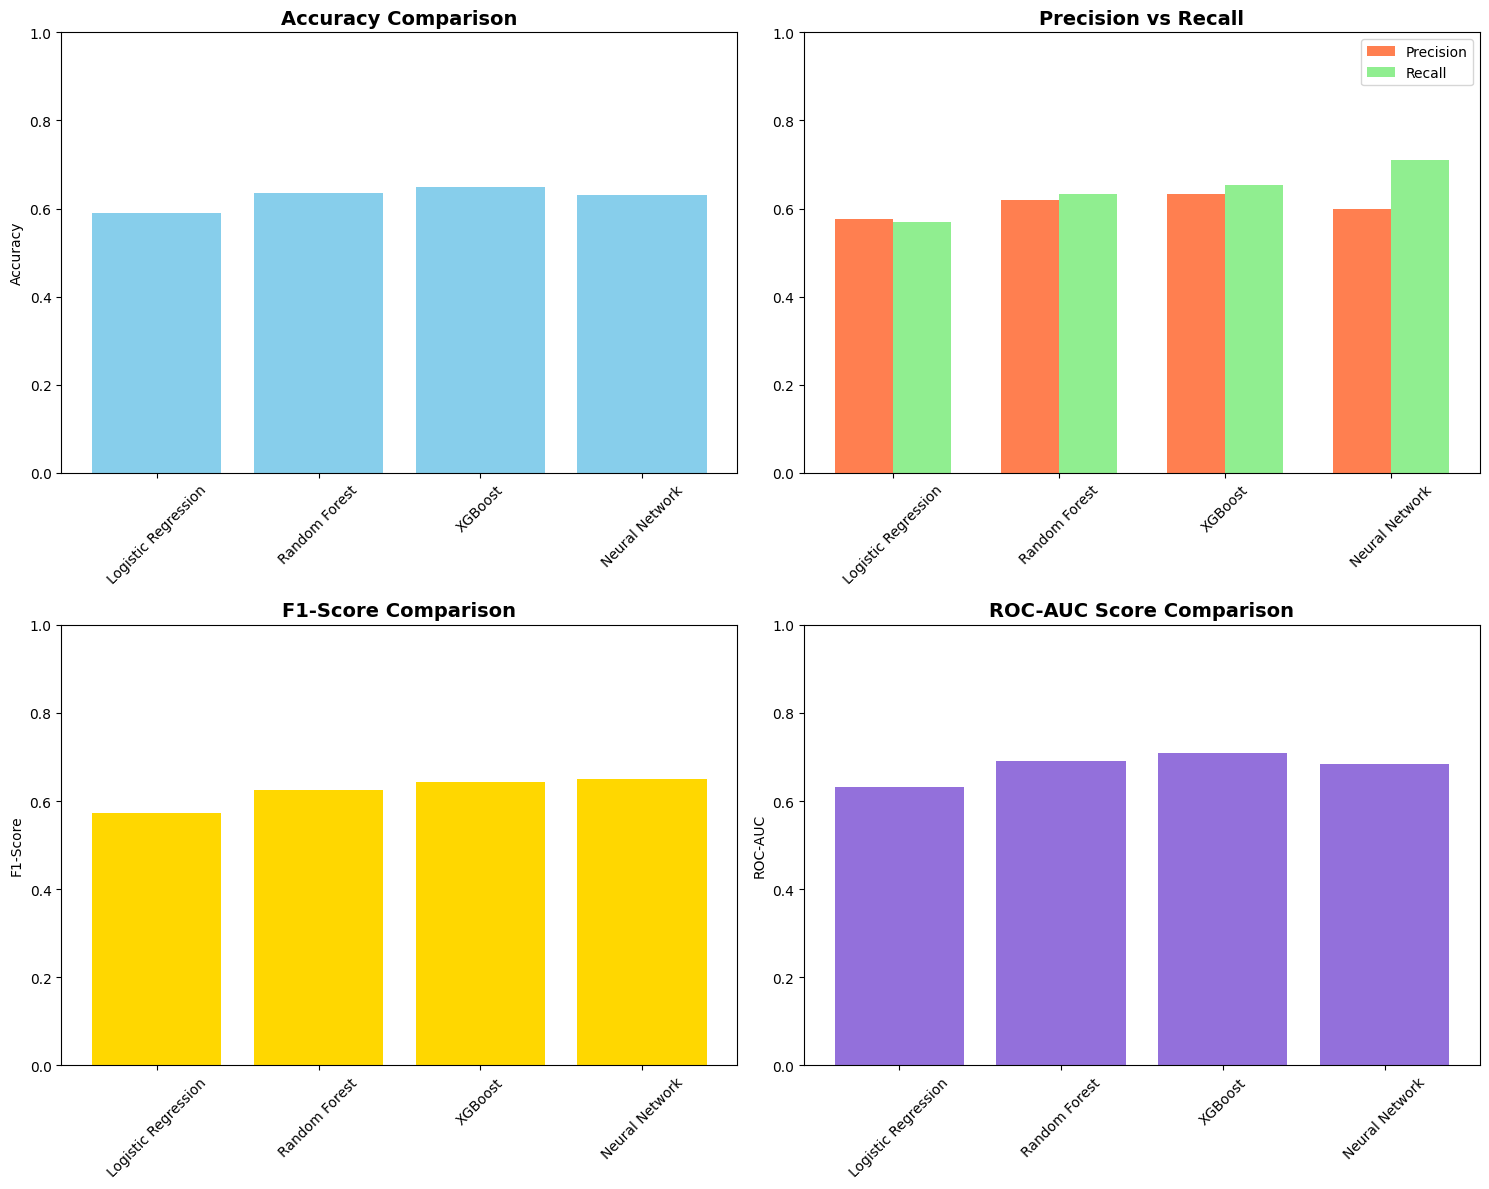


Confusion Matrix for Neural Network:


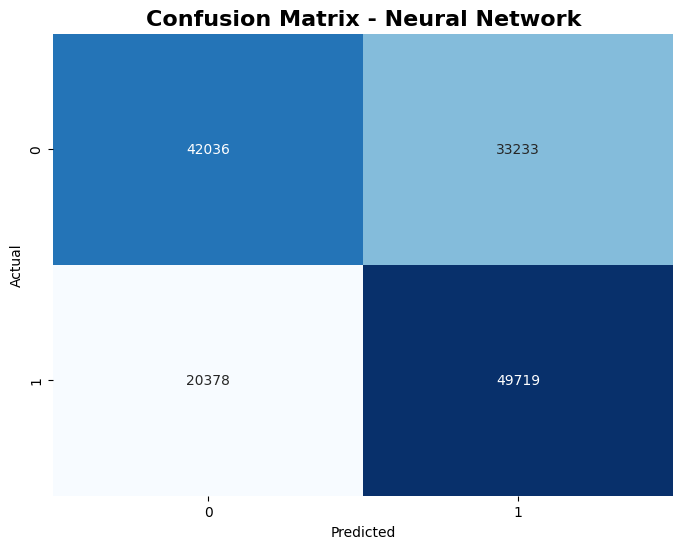

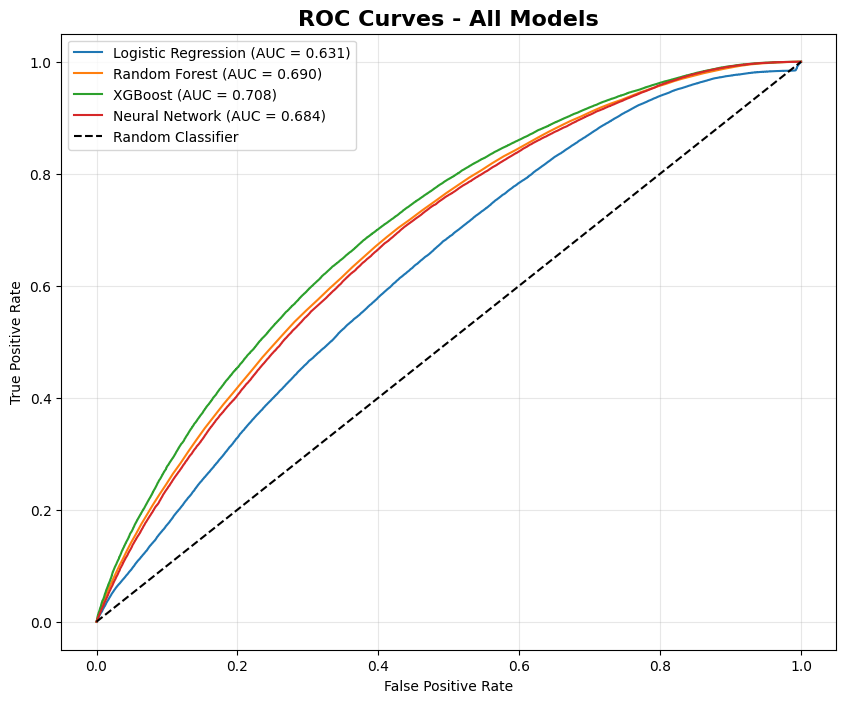


✓ Visualizations saved to Google Drive!

FINAL SUMMARY

📊 Dataset: 484551 flights analyzed
📈 Models trained: 4
🏆 Best model: Neural Network
✓ F1-Score: 0.6497
✓ Accuracy: 0.6312
✓ ROC-AUC: 0.6837

📁 All outputs saved to Google Drive!
PROJECT COMPLETED SUCCESSFULLY!


In [ ]:
# ============================================================================
# FLIGHT DELAY PREDICTION - COMPLETE ML PROJECT
# CS4552 Machine Learning Project
# ============================================================================

# MOUNT GOOGLE DRIVE
# ----------------------------------------------------------------------------
print("Mounting Google Drive...")
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted successfully!\n")

# STEP 1: INSTALL AND IMPORT LIBRARIES
# ----------------------------------------------------------------------------
print("Installing required libraries...")
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!\n")

# ============================================================================
# STEP 2: LOAD THE DATASET
# ============================================================================
print("="*70)
print("STEP 2: LOADING DATASET")
print("="*70)

# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/Flight_delays.csv')

print(f"Dataset loaded successfully!")
print(f"Total records: {len(df)}")
print(f"Total features: {df.shape[1]}")
print("\nFirst few rows:")
print(df.head())

# ============================================================================
# STEP 3: DATA EXPLORATION
# ============================================================================
print("\n" + "="*70)
print("STEP 3: DATA EXPLORATION")
print("="*70)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

# ============================================================================
# STEP 4: CREATE TARGET VARIABLE (DELAYED = 1 IF DELAY >= 15 MIN)
# ============================================================================
print("\n" + "="*70)
print("STEP 4: CREATING TARGET VARIABLE")
print("="*70)

# Assuming there's an 'ARR_DELAY' or 'ARRIVAL_DELAY' column
# Change column name based on your actual dataset
if 'ARR_DELAY' in df.columns:
    delay_col = 'ARR_DELAY'
elif 'ARRIVAL_DELAY' in df.columns:
    delay_col = 'ARRIVAL_DELAY'
else:
    delay_col = df.columns[-1]  # Use last column if not found

# Create binary target: 1 if delayed >= 15 minutes, 0 otherwise
df['DELAYED'] = (df[delay_col] >= 15).astype(int)

print(f"Target variable created: DELAYED (1 if delay >= 15 min)")
print(f"\nClass distribution:")
print(df['DELAYED'].value_counts())
print(f"\nPercentage delayed: {df['DELAYED'].mean()*100:.2f}%")

# ============================================================================
# STEP 5: SELECT FEATURES
# ============================================================================
print("\n" + "="*70)
print("STEP 5: FEATURE SELECTION")
print("="*70)

# Select relevant features (adjust based on your dataset columns)
# Common columns in flight delay datasets
feature_candidates = ['MONTH', 'DAY_OF_WEEK', 'DEP_TIME', 'ARR_TIME',
                      'CARRIER', 'ORIGIN', 'DEST', 'DISTANCE',
                      'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY']

# Keep only columns that exist in the dataset
features = [col for col in feature_candidates if col in df.columns]

if len(features) == 0:
    # If none found, use first few columns
    features = df.columns[:5].tolist()

print(f"Selected features: {features}")

# ============================================================================
# STEP 6: DATA PREPROCESSING
# ============================================================================
print("\n" + "="*70)
print("STEP 6: DATA PREPROCESSING")
print("="*70)

# Create a clean dataset
df_clean = df[features + ['DELAYED']].copy()

# Remove rows with missing values
df_clean = df_clean.dropna()
print(f"Records after removing missing values: {len(df_clean)}")

# Separate features and target
X = df_clean[features]
y = df_clean['DELAYED']

# Encode categorical variables
le = LabelEncoder()
categorical_cols = X.select_dtypes(include=['object']).columns

print(f"\nEncoding categorical features: {list(categorical_cols)}")
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✓ Data preprocessing completed!")

# ============================================================================
# STEP 7: SPLIT DATA (70% TRAIN, 30% TEST)
# ============================================================================
print("\n" + "="*70)
print("STEP 7: SPLITTING DATA")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X_scaled)*100:.1f}%)")

# ============================================================================
# STEP 8: TRAIN MODELS
# ============================================================================
print("\n" + "="*70)
print("STEP 8: TRAINING MODELS")
print("="*70)

# Dictionary to store models and results
models = {}
results = {}

# MODEL 1: LOGISTIC REGRESSION (BASELINE)
print("\nTraining Model 1: Logistic Regression (Baseline)...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
models['Logistic Regression'] = log_reg
print("✓ Logistic Regression trained!")

# MODEL 2: RANDOM FOREST
print("\nTraining Model 2: Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("✓ Random Forest trained!")

# MODEL 3: XGBOOST
print("\nTraining Model 3: XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
models['XGBoost'] = xgb
print("✓ XGBoost trained!")

# MODEL 4: NEURAL NETWORK (USING TENSORFLOW)
print("\nTraining Model 4: Neural Network...")
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout

    nn_model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    nn_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

    nn_model.fit(X_train, y_train, epochs=10, batch_size=32,
                 verbose=0, validation_split=0.2)

    models['Neural Network'] = nn_model
    print("✓ Neural Network trained!")
except:
    print("⚠ Neural Network training skipped (TensorFlow not available)")

print("\n✓ All models trained successfully!")

# ============================================================================
# STEP 9: EVALUATE MODELS
# ============================================================================
print("\n" + "="*70)
print("STEP 9: MODEL EVALUATION")
print("="*70)

for name, model in models.items():
    print(f"\n{name}:")
    print("-" * 50)

    # Make predictions
    if name == 'Neural Network':
        y_pred_proba = model.predict(X_test).flatten()
        y_pred = (y_pred_proba >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    # Print results
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

# ============================================================================
# STEP 10: RESULTS COMPARISON TABLE
# ============================================================================
print("\n" + "="*70)
print("STEP 10: RESULTS COMPARISON")
print("="*70)

results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
print("\n" + results_df.to_string())

# Find best model
best_model = results_df['F1-Score'].idxmax()
print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   F1-Score: {results_df.loc[best_model, 'F1-Score']:.4f}")

# ============================================================================
# STEP 11: VISUALIZATIONS
# ============================================================================
print("\n" + "="*70)
print("STEP 11: GENERATING VISUALIZATIONS")
print("="*70)

# Plot 1: Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
axes[0, 0].bar(results_df.index, results_df['Accuracy'], color='skyblue')
axes[0, 0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=45)

# Precision vs Recall
x = np.arange(len(results_df))
width = 0.35
axes[0, 1].bar(x - width/2, results_df['Precision'], width, label='Precision', color='coral')
axes[0, 1].bar(x + width/2, results_df['Recall'], width, label='Recall', color='lightgreen')
axes[0, 1].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(results_df.index, rotation=45)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])

# F1-Score comparison
axes[1, 0].bar(results_df.index, results_df['F1-Score'], color='gold')
axes[1, 0].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)

# ROC-AUC comparison
axes[1, 1].bar(results_df.index, results_df['ROC-AUC'], color='mediumpurple')
axes[1, 1].set_title('ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Confusion Matrix for Best Model
print(f"\nConfusion Matrix for {best_model}:")
cm = confusion_matrix(y_test, results[best_model]['y_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - {best_model}', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: ROC Curves
plt.figure(figsize=(10, 8))
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["ROC-AUC"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('/content/drive/MyDrive/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations saved to Google Drive!")

# ============================================================================
# STEP 12: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"\n📊 Dataset: {len(df_clean)} flights analyzed")
print(f"📈 Models trained: {len(models)}")
print(f"🏆 Best model: {best_model}")
print(f"✓ F1-Score: {results_df.loc[best_model, 'F1-Score']:.4f}")
print(f"✓ Accuracy: {results_df.loc[best_model, 'Accuracy']:.4f}")
print(f"✓ ROC-AUC: {results_df.loc[best_model, 'ROC-AUC']:.4f}")

print("\n📁 All outputs saved to Google Drive!")
print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

print("Features actually used in the model:")
print(features)
print(f"\nTotal number of features: {len(features)}")


```
[# This is formatted as code](https://)
```



print("Features actually used in the model:")
print(features)
print(f"\nTotal number of features: {len(features)}")


In [ ]:
print("Features actually used in the model:")
print(features)
print(f"\nTotal number of features: {len(features)}")

Features actually used in the model:
['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime']

Total number of features: 5


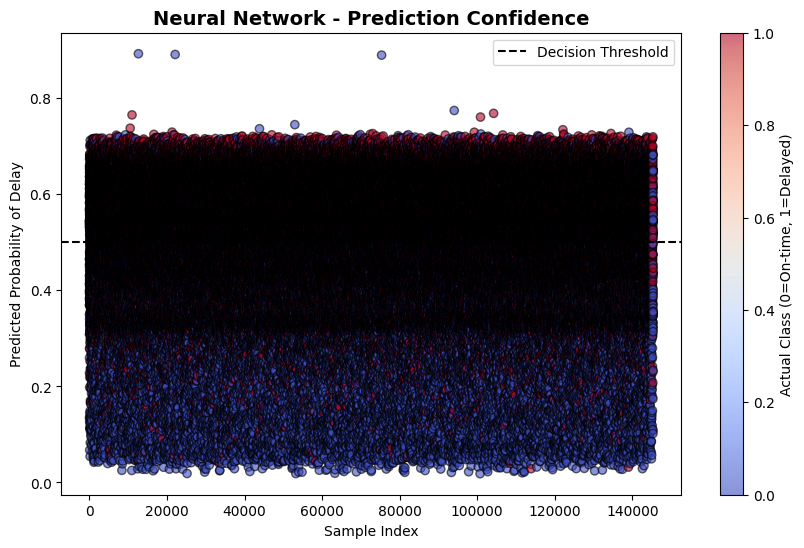


DETAILED CLASSIFICATION REPORTS

Logistic Regression:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.60      0.61      0.61     75269
           1       0.58      0.57      0.57     70097

    accuracy                           0.59    145366
   macro avg       0.59      0.59      0.59    145366
weighted avg       0.59      0.59      0.59    145366


Random Forest:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.65      0.64      0.64     75269
           1       0.62      0.63      0.63     70097

    accuracy                           0.64    145366
   macro avg       0.63      0.64      0.63    145366
weighted avg       0.64      0.64      0.64    145366


XGBoost:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.65      0.66     75269
   

In [ ]:
# Add this section after your model evaluation code

# ============================================================================
# ADDITIONAL VISUALIZATIONS - PREDICTION PLOTS
# ============================================================================

# For Neural Network - show prediction confidence
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), results['Neural Network']['y_pred_proba'],
            c=y_test, cmap='coolwarm', alpha=0.6, edgecolors='k')
plt.axhline(y=0.5, color='black', linestyle='--', label='Decision Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Probability of Delay')
plt.title('Neural Network - Prediction Confidence', fontsize=14, fontweight='bold')
plt.colorbar(label='Actual Class (0=On-time, 1=Delayed)')
plt.legend()
plt.savefig('/content/drive/MyDrive/nn_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report for each model
from sklearn.metrics import classification_report

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for name in models.keys():
    print(f"\n{name}:")
    print("-" * 50)
    print(classification_report(y_test, results[name]['y_pred']))